In [1]:
import matplotlib as plt
import datetime


   step  portfolio_value  weight_0  weight_1  weight_2  weight_3  weight_4  \
0     0     99271.616524  0.095649  0.752979  0.035233  0.036657  0.042841   
1     1     98117.527404  0.109841  0.697751  0.055978  0.046333  0.050708   
2     2     97868.375737  0.123664  0.615814  0.082776  0.064708  0.052914   
3     3     99857.555662  0.126993  0.627911  0.078185  0.071553  0.037369   
4     4     99837.568330  0.148632  0.616848  0.074715  0.072308  0.037154   

   weight_5  
0  0.036641  
1  0.039389  
2  0.060124  
3  0.057988  
4  0.050343  


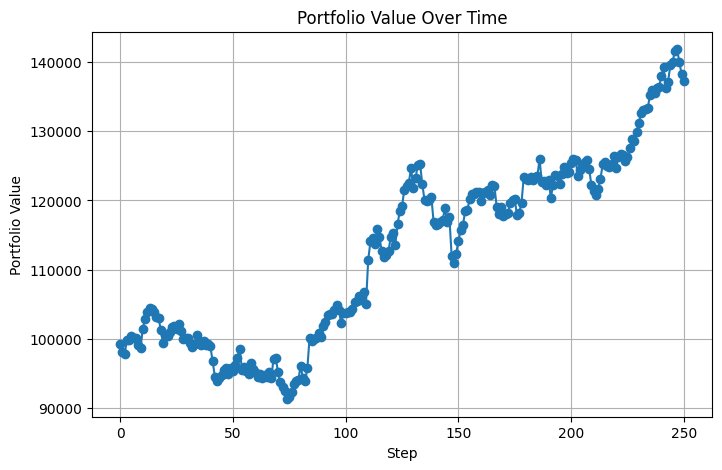

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas_ta as ta

# 1) Load the CSV
df = pd.read_csv("portfolio_values_episode_11.csv")  # Replace with your actual filename

# 2) Quick check of the first few rows
print(df.head())

# 3) Plot portfolio_value over step
plt.figure(figsize=(8,5))
plt.plot(df["step"], df["portfolio_value"], marker='o')
plt.xlabel("Step")
plt.ylabel("Portfolio Value")
plt.title("Portfolio Value Over Time")
plt.grid(True)
plt.show()


   step  portfolio_value  weight_0  weight_1  weight_2  weight_3  weight_4  \
0     0     95467.964988  0.071796  0.238760  0.067116  0.183602  0.115416   
1     1     96544.637679  0.072710  0.239486  0.067165  0.183051  0.115270   
2     2     94535.366384  0.073089  0.238372  0.067107  0.184913  0.115084   
3     3     96697.415519  0.073487  0.237231  0.067748  0.184110  0.115721   
4     4     98963.899311  0.074542  0.238787  0.067816  0.184869  0.115736   

   weight_5  
0  0.323309  
1  0.322317  
2  0.321435  
3  0.321704  
4  0.318251  


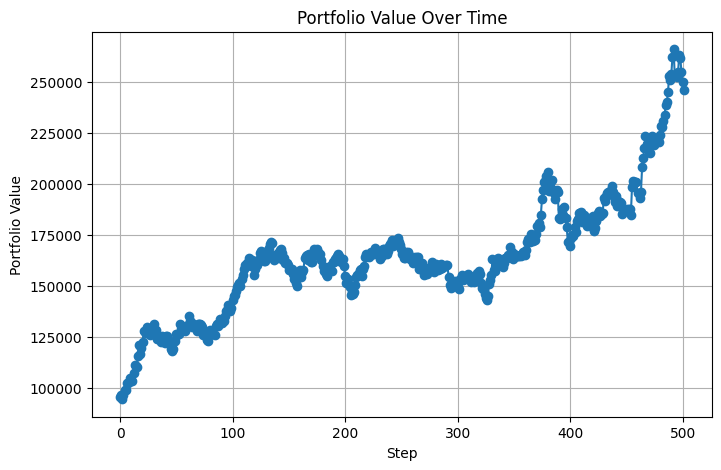

In [2]:
# 1) Load the CSV
df = pd.read_csv("portfolio_values_episode_9.csv")  # Replace with your actual filename

# 2) Quick check of the first few rows
print(df.head())

# 3) Plot portfolio_value over step
plt.figure(figsize=(8,5))
plt.plot(df["step"], df["portfolio_value"], marker='o')
plt.xlabel("Step")
plt.ylabel("Portfolio Value")
plt.title("Portfolio Value Over Time")
plt.grid(True)
plt.show()


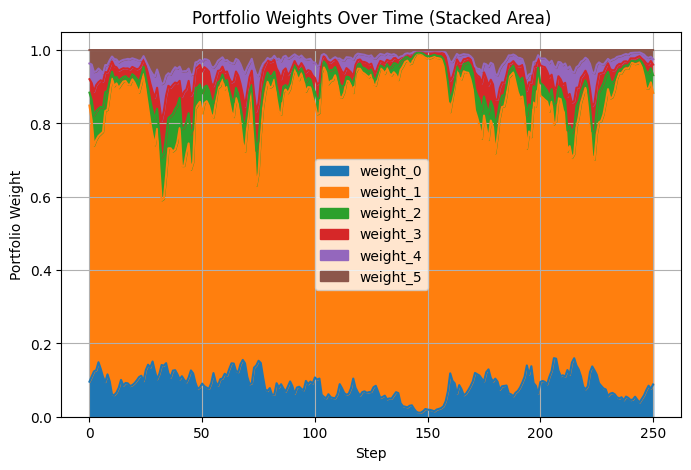

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("portfolio_values_episode_11.csv")

# Gather just the weight columns into a sub-DataFrame
weight_cols = [c for c in df.columns if c.startswith("weight_")]
df_weights = df[weight_cols]

# Stacked area plot
df_weights.plot.area(figsize=(8,5))
plt.xlabel("Step")
plt.ylabel("Portfolio Weight")
plt.title("Portfolio Weights Over Time (Stacked Area)")
plt.legend()
plt.grid(True)
plt.show()


[*********************100%***********************]  5 of 5 completed


Portfolio performance from 2024-01-01 to 2025-01-01
Final portfolio value: $143,514.23


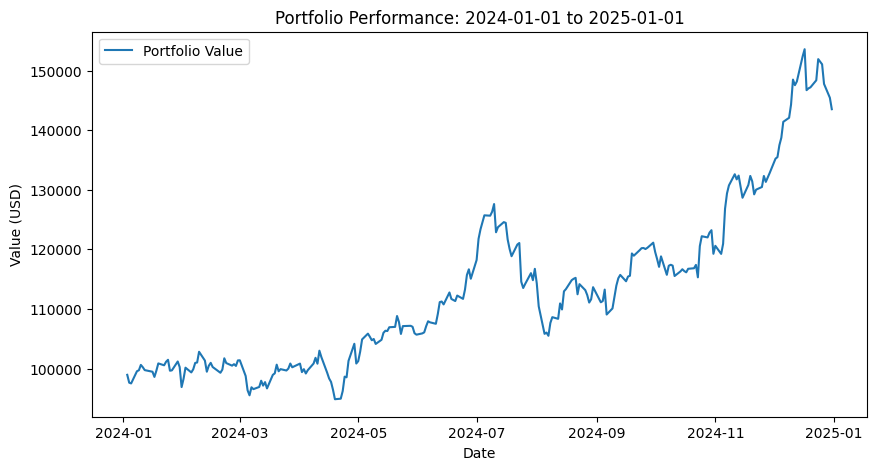

[*********************100%***********************]  5 of 5 completed


Portfolio performance from 2011-01-01 to 2012-01-01
Final portfolio value: $107,655.15


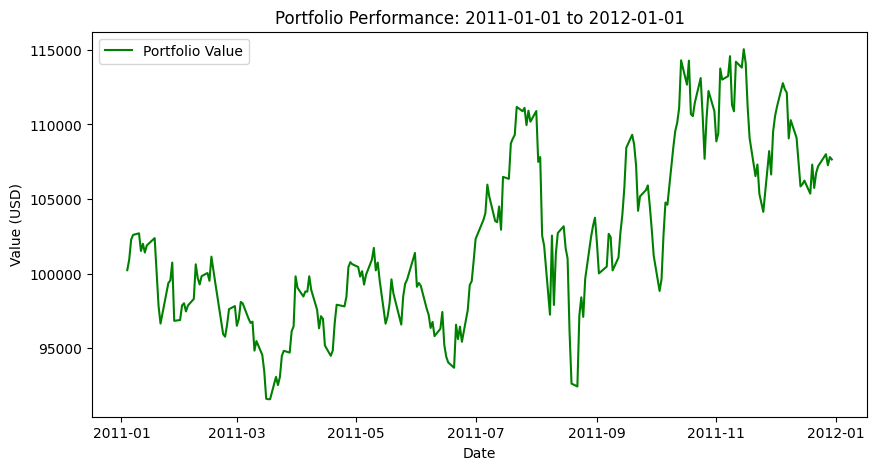

In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def backtest_portfolio(tickers, start_date, end_date, initial_investment=100000):
    """
    Downloads price data from Yahoo Finance for the given ticker symbols and date range,
    calculates the performance of an equal-weighted portfolio, and returns a DataFrame
    with daily portfolio value and the final value.
    """
    
    # Download Adjusted Close prices
    data = yf.download(tickers, start=start_date, end=end_date)['Close']
    
    # Drop rows with missing data (optional, but helps avoid NA issues)
    data.dropna(inplace=True)

    # Calculate daily returns
    daily_returns = data.pct_change().dropna()
    
    # Equal weights for each ticker
    weights = np.array([1.0 / len(tickers)] * len(tickers))
    
    # Calculate portfolio daily returns
    portfolio_daily_returns = daily_returns.dot(weights)
    
    # Calculate cumulative returns
    cumulative_returns = (1 + portfolio_daily_returns).cumprod()
    
    # Convert cumulative returns to actual portfolio value
    portfolio_value = initial_investment * cumulative_returns
    
    # Final portfolio value
    final_value = portfolio_value.iloc[-1] if not portfolio_value.empty else np.nan
    
    # Prepare a DataFrame with daily portfolio value
    results_df = pd.DataFrame({
        'Portfolio Value': portfolio_value
    })
    
    return results_df, final_value

# Define the tickers and initial investment
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA"]
# tickers = ['AMC', 'PLUG', 'SAFE', 'NVAX', 'LCID']
initial_investment = 100000

# Period 1: 2023-01-01 to 2025-01-01
start_date_1 = "2024-01-01"
end_date_1 = "2025-01-01"

results_1, final_val_1 = backtest_portfolio(tickers, start_date_1, end_date_1, initial_investment)

print(f"Portfolio performance from {start_date_1} to {end_date_1}")
if not results_1.empty:
    print(f"Final portfolio value: ${final_val_1:,.2f}")
else:
    print("No data was returned for this period. (Future data may not be fully available)")

# Plot the portfolio value over time for period 1 (optional)
if not results_1.empty:
    plt.figure(figsize=(10, 5))
    plt.plot(results_1.index, results_1['Portfolio Value'], label='Portfolio Value')
    plt.title(f"Portfolio Performance: {start_date_1} to {end_date_1}")
    plt.xlabel("Date")
    plt.ylabel("Value (USD)")
    plt.legend()
    plt.show()

# Period 2: 2011-01-01 to 2012-01-01
start_date_2 = "2011-01-01"
end_date_2 = "2012-01-01"

results_2, final_val_2 = backtest_portfolio(tickers, start_date_2, end_date_2, initial_investment)

print(f"Portfolio performance from {start_date_2} to {end_date_2}")
if not results_2.empty:
    print(f"Final portfolio value: ${final_val_2:,.2f}")
else:
    print("No data was returned for this period. (Check if all tickers existed historically)")

# Plot the portfolio value over time for period 2 (optional)
if not results_2.empty:
    plt.figure(figsize=(10, 5))
    plt.plot(results_2.index, results_2['Portfolio Value'], label='Portfolio Value', color='green')
    plt.title(f"Portfolio Performance: {start_date_2} to {end_date_2}")
    plt.xlabel("Date")
    plt.ylabel("Value (USD)")
    plt.legend()
    plt.show()


In [5]:
# 1. Download data
start_date = "2012-01-01"
end_date = "2023-01-01"
data = yf.download(tickers, start=start_date, end=end_date, interval="1d")

# 2. Select relevant OHLCV columns
data = data["Open High Low Close Volume".split()]
print("Data after selecting OHLCV columns:")
print(data.head())

# 3. Stack on level=1 (the TICKER level), then reset index
data = data.stack(level=1).reset_index()
print("Data after stacking and resetting index:")
print(data.head())

# 4. Rename columns for clarity
data = data.rename(columns={"level_0": "Date", "level_1": "Ticker"})
print("Data after renaming columns:")
print(data.head())

# Compute indicators per Ticker
# We'll group by Ticker, then apply pandas_ta
def compute_indicators(df_):
    df_ = df_.sort_values("Date").copy()
    df_["RSI"] = ta.rsi(df_["Close"], length=14)
    macd_df = ta.macd(df_["Close"], fast=12, slow=26, signal=9)
    df_["MACD"] = macd_df["MACD_12_26_9"]
    return df_

data = data.groupby("Ticker", group_keys=False).apply(compute_indicators)

# Now pivot: index=(Date,Ticker), columns=(Open,High,Low,Close,Volume,RSI,MACD)
data = data.set_index(["Date","Ticker"])
data = data[["Open","High","Low","Close","Volume","RSI","MACD"]]
print(data)


[*********************100%%**********************]  5 of 5 completed
C:\Users\amina\AppData\Local\Temp\ipykernel_3800\2223912169.py:12: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  data = data.stack(level=1).reset_index()


Data after selecting OHLCV columns:
Price            Open                                               High  \
Ticker           AAPL    AMZN      GOOGL       MSFT      TSLA       AAPL   
Date                                                                       
2012-01-03  14.621429  8.7945  16.339840  26.549999  1.929333  14.732143   
2012-01-04  14.642857  8.9605  16.642391  26.820000  1.880667  14.810000   
2012-01-05  14.819643  8.7970  16.569820  27.379999  1.850667  14.948214   
2012-01-06  14.991786  8.9035  16.495245  27.530001  1.813333  15.098214   
2012-01-09  15.196429  9.1380  16.178679  28.049999  1.800000  15.276786   

Price                                               ...      Close          \
Ticker        AMZN      GOOGL       MSFT      TSLA  ...       AAPL    AMZN   
Date                                                ...                      
2012-01-03  8.9740  16.720470  26.959999  1.966667  ...  14.686786  8.9515   
2012-01-04  9.0250  16.773024  27.469999  1

C:\Users\amina\AppData\Local\Temp\ipykernel_3800\2223912169.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby("Ticker", group_keys=False).apply(compute_indicators)


In [13]:
# Convert start_date to datetime
start_dt = pd.to_datetime(start_date)
# Subtract ~30 days to ensure we have enough data for indicators
pull_dt = start_dt - datetime.timedelta(days=40)

# 1) Download from pull_dt to end_date
data = yf.download(
        tickers,
        start=pull_dt.strftime("%Y-%m-%d"),
        end=end_date,
        interval="1d"
    )
# 2) Keep relevant columns
data = data[["Open","High","Low","Close","Volume"]]
# 3) Reshape
data = data.stack(level=1).reset_index()
data = data.rename(columns={"level_0":"Date","level_1":"Ticker"})
data = data.set_index(["Date","Ticker"]).sort_index()

# 4) Compute indicators
def do_indicators(df_):
    df_ = df_.sort_values("Date").copy()
    df_["RSI"] = ta.rsi(df_["Close"], length=14)
    macd_df = ta.macd(df_["Close"], fast=12, slow=26, signal=9)
    df_["MACD"] = macd_df["MACD_12_26_9"]
    return df_

data = data.groupby("Ticker", group_keys=False).apply(do_indicators)

# 5) Fill missing values
data = data.groupby(level="Ticker").ffill()  # forward-fill missing RSI/MACD for each ticker
# data = data.fillna(0.0)  # if you prefer 0 for any leftover

# 6) Drop all rows strictly before official start_date
data = data.loc[data.index.get_level_values("Date") >= start_dt] 
print(data)

[*********************100%%**********************]  5 of 5 completed

Price                    Open        High         Low       Close     Volume  \
Date       Ticker                                                              
2012-01-03 AAPL     14.621429   14.732143   14.607143   14.686786  302220800   
           AMZN      8.794500    8.974000    8.777500    8.951500  102216000   
           GOOGL    16.339840   16.720470   16.325577   16.651901  146912940   
           MSFT     26.549999   26.959999   26.389999   26.770000   64731500   
           TSLA      1.929333    1.966667    1.843333    1.872000   13921500   
...                       ...         ...         ...         ...        ...   
2022-12-30 AAPL    128.410004  129.949997  127.430000  129.929993   77034200   
           AMZN     83.120003   84.050003   82.470001   84.000000   62401200   
           GOOGL    86.980003   88.300003   86.570000   88.230003   23986300   
           MSFT    238.210007  239.960007  236.660004  239.820007   21938500   
           TSLA    119.949997  124.48000


C:\Users\amina\AppData\Local\Temp\ipykernel_3800\3625414888.py:16: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  data = data.stack(level=1).reset_index()


[*********************100%***********************]  5 of 5 completed


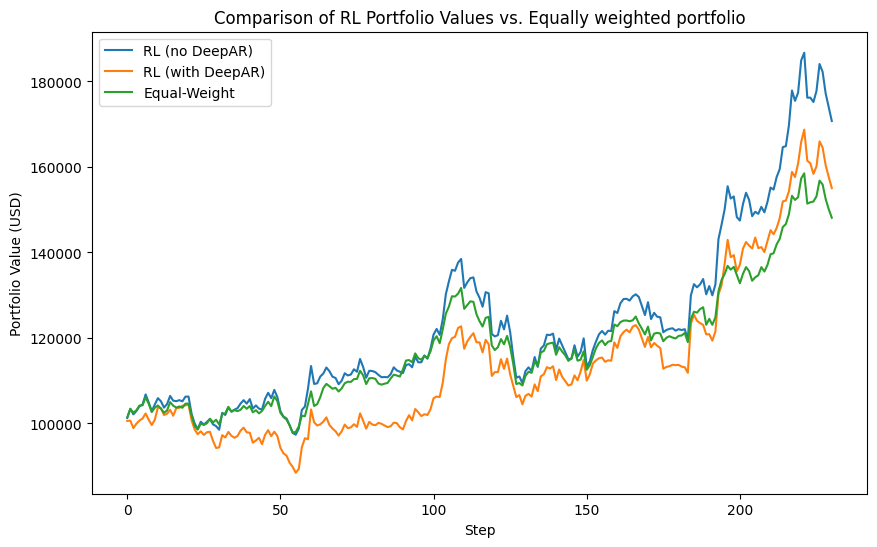

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

def backtest_equal_weight_portfolio(tickers, start_date, end_date, initial_investment=100000, skip_days=20):
    """
    Downloads price data from Yahoo Finance for the given tickers and date range,
    then skips the first `skip_days` of trading (to match RL warmup).
    Returns a DataFrame with daily portfolio value and the final value.
    """
    # 1) Download adjusted close prices
    data = yf.download(tickers, start=start_date, end=end_date)['Close']
    
    # 2) Drop rows with missing data (optional)
    data.dropna(inplace=True)
    
    # 3) Skip the first `skip_days` to align with RL’s 20-day lookback
    data = data.iloc[skip_days:].copy()
    
    # 4) Calculate daily returns
    daily_returns = data.pct_change().dropna()
    
    # 5) Calculate equal-weighted portfolio daily returns
    weights = np.array([1.0 / len(tickers)] * len(tickers))
    portfolio_daily_returns = daily_returns.dot(weights)
    
    # 6) Calculate the cumulative returns
    cumulative_returns = (1 + portfolio_daily_returns).cumprod()
    
    # 7) Convert those to an actual portfolio value
    portfolio_value = initial_investment * cumulative_returns
    
    # Build results in a DataFrame
    results_df = pd.DataFrame({'Portfolio Value': portfolio_value})
    final_value = portfolio_value.iloc[-1] if not portfolio_value.empty else np.nan
    
    return results_df, final_value

# ================================
# Example: Using the backtest code
# ================================
if __name__ == "__main__":
    # 1) Read your RL results from CSV
    df_ep13 = pd.read_csv("portfolio_values_episode_13.csv")
    df_ep14 = pd.read_csv("portfolio_values_episode_14.csv")
    
    # 2) Get Equal-Weighted Performance, skipping 20 days
    tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA"]
    start_date = "2024-01-01"
    end_date   = "2025-01-01"
    initial_investment = 100000
    
    eq_df, final_eq_val = backtest_equal_weight_portfolio(
        tickers=tickers,
        start_date=start_date,
        end_date=end_date,
        initial_investment=initial_investment,
        skip_days=20  # skip first 20 trading days
    )
    
    # (Optional) Make the index numeric to plot “steps” instead of “dates”
    eq_df_reset = eq_df.reset_index(drop=True)
    eq_df_reset['step'] = eq_df_reset.index
    eq_df_reset.rename(columns={'Portfolio Value': 'portfolio_value'}, inplace=True)
    
    # 3) Plot comparison of RL Episode 13, RL Episode 14, and the Equal-Weight
    plt.figure(figsize=(10, 6))
    
    plt.plot(df_ep13['step'], df_ep13['portfolio_value'], label='RL (no DeepAR)')
    plt.plot(df_ep14['step'], df_ep14['portfolio_value'], label='RL (with DeepAR)')
    plt.plot(eq_df_reset['step'], eq_df_reset['portfolio_value'], label='Equal-Weight')
    
    plt.xlabel("Step")
    plt.ylabel("Portfolio Value (USD)")
    plt.title("Comparison of RL Portfolio Values vs. Equally weighted portfolio")
    plt.legend()
    plt.show()


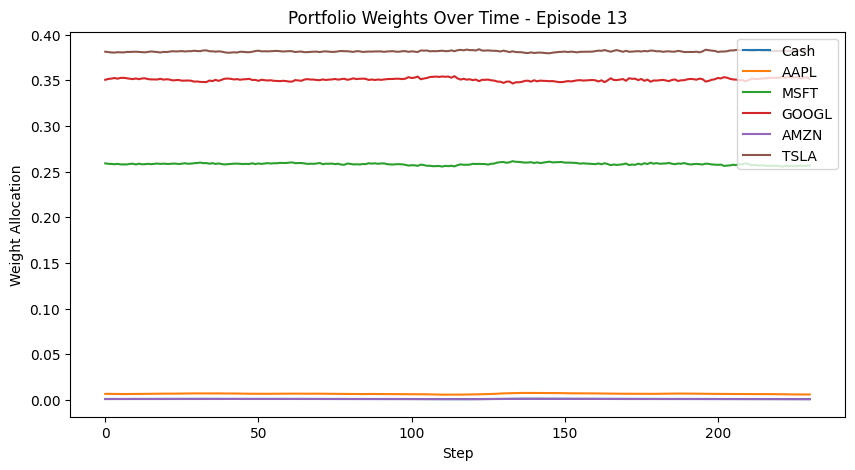

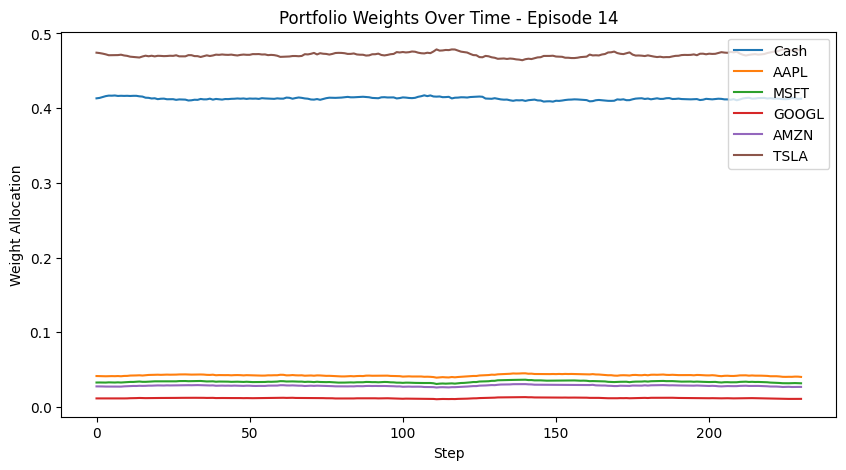

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# CSV files from your RL training
csv_ep13 = "portfolio_values_episode_13.csv"
csv_ep14 = "portfolio_values_episode_14.csv"

# Read CSVs
df_ep13 = pd.read_csv(csv_ep13)
df_ep14 = pd.read_csv(csv_ep14)

# Define labels for the assets:
# weight_0 -> Cash, weight_1 -> AAPL, weight_2 -> MSFT, etc.
labels = ["Cash", "AAPL", "MSFT", "GOOGL", "AMZN", "TSLA"]

# ================================
# Line Plot for Episode 13
# ================================
plt.figure(figsize=(10, 5))

# Plot each weight as its own line
for i, label in enumerate(labels):
    plt.plot(df_ep13["step"], df_ep13[f"weight_{i}"], label=label)

plt.title("Portfolio Weights Over Time - Episode 13")
plt.xlabel("Step")
plt.ylabel("Weight Allocation")
plt.legend(loc="upper right")
plt.show()

# ================================
# Line Plot for Episode 14
# ================================
plt.figure(figsize=(10, 5))

# Plot each weight as its own line
for i, label in enumerate(labels):
    plt.plot(df_ep14["step"], df_ep14[f"weight_{i}"], label=label)

plt.title("Portfolio Weights Over Time - Episode 14")
plt.xlabel("Step")
plt.ylabel("Weight Allocation")
plt.legend(loc="upper right")
plt.show()



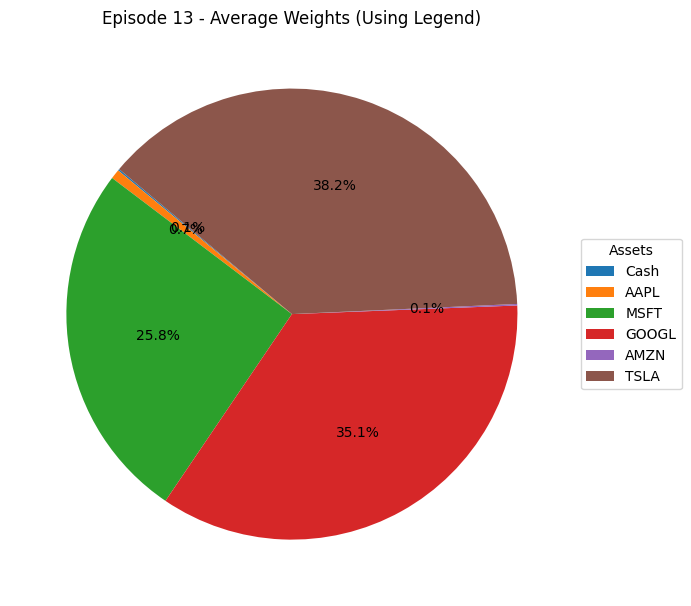

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------
# Load Data
# -----------
csv_ep13 = "portfolio_values_episode_13.csv"
df_ep13 = pd.read_csv(csv_ep13)

labels = ["Cash", "AAPL", "MSFT", "GOOGL", "AMZN", "TSLA"]
avg_weights_ep13 = [
    df_ep13["weight_0"].mean(),
    df_ep13["weight_1"].mean(),
    df_ep13["weight_2"].mean(),
    df_ep13["weight_3"].mean(),
    df_ep13["weight_4"].mean(),
    df_ep13["weight_5"].mean()
]

# -----------
# Pie Chart
# -----------
plt.figure(figsize=(7, 7))

# Labels=None so the text on the slices won't contain the asset names – 
# only percentages via autopct. We'll rely on a separate legend instead.
wedges, text_objs, pct_objs = plt.pie(
    avg_weights_ep13,
    labels=None,           # No direct slice labels
    autopct='%1.1f%%',     # Show slice percentages
    startangle=140
)

# Legend: map each wedge to the corresponding label
plt.legend(wedges, labels, title="Assets", loc="center left", bbox_to_anchor=(1, 0.5))

plt.title("Episode 13 - Average Weights (Using Legend)")
plt.tight_layout()
plt.show()


[*********************100%***********************]  5 of 5 completed


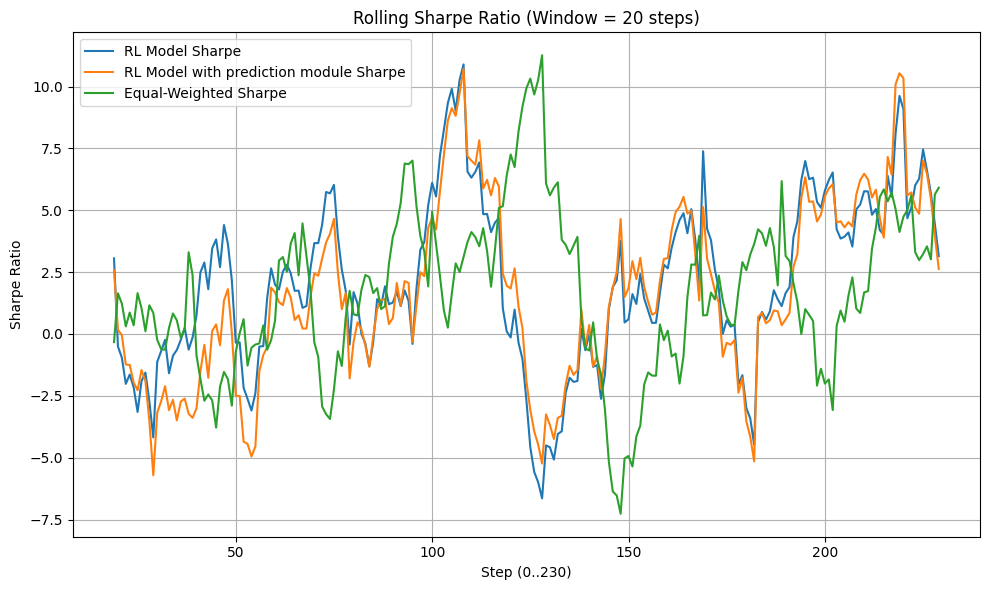

In [17]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def build_equal_weight_portfolio(tickers, start_date, end_date, initial_investment=100_000):
    """
    Downloads daily closing prices from Yahoo Finance for `tickers`,
    computes an equal-weighted portfolio value, and returns
    a DataFrame with a 'portfolio_value' column (indexed by date).
    """
    price_data = yf.download(tickers, start=start_date, end=end_date)["Close"].dropna()
    
    # Daily returns
    daily_returns = price_data.pct_change().dropna()
    
    # Equal weights
    weights = np.array([1.0 / len(tickers)] * len(tickers))
    
    # Portfolio daily returns
    port_daily_returns = daily_returns.dot(weights)
    
    # Cumulative returns
    port_cum_returns = (1 + port_daily_returns).cumprod()
    
    # Convert to monetary value
    port_values = initial_investment * port_cum_returns
    
    # Return as a DataFrame with date index
    df_eq = pd.DataFrame({"portfolio_value": port_values})
    return df_eq

def compute_rolling_sharpe_ratio(portfolio_values, window=20, risk_free_rate=0.0, annual_factor=252):
    """
    Computes a rolling Sharpe ratio for a given 'portfolio_values' series.
    Assumes each row is one "step" (e.g., daily).
    """
    # Per-step returns
    returns = portfolio_values.pct_change().dropna()
    
    # Subtract risk-free if desired
    adj_returns = returns - risk_free_rate
    
    # Rolling stats
    rolling_mean = adj_returns.rolling(window).mean()
    rolling_std = adj_returns.rolling(window).std()
    
    # Rolling Sharpe
    sharpe_series = (rolling_mean / rolling_std) * np.sqrt(annual_factor)
    return sharpe_series

# -------------------------------
# 1) Build equal-weighted DataFrame
# -------------------------------
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA"]
start_date = "2024-01-01"
end_date   = "2025-01-01"
initial_investment = 100_000

df_eq_full = build_equal_weight_portfolio(tickers, start_date, end_date, initial_investment)

# Suppose your RL environment has EXACTLY 231 steps. We'll truncate to 231 rows.
desired_steps = 231

# Safety check: make sure df_eq_full has at least 231 rows
if len(df_eq_full) < desired_steps:
    raise ValueError(f"Equal-weighted data has only {len(df_eq_full)} rows, "
                     f"need at least {desired_steps}.")

df_eq_231 = df_eq_full.iloc[:desired_steps].copy()

# Reset the index so it runs from 0..230
df_eq_231.reset_index(drop=True, inplace=True)
df_eq_231["step"] = df_eq_231.index  # 0..230

# -------------------------------
# 2) Read RL CSVs (Episode 13 & 14)
# -------------------------------
df_ep13 = pd.read_csv("portfolio_values_episode_13.csv")
df_ep14 = pd.read_csv("portfolio_values_episode_14.csv")

# Ensure both have at least 231 steps
if len(df_ep13) < desired_steps:
    raise ValueError(f"Episode 13 CSV has only {len(df_ep13)} rows, need 231.")
if len(df_ep14) < desired_steps:
    raise ValueError(f"Episode 14 CSV has only {len(df_ep14)} rows, need 231.")

# Truncate to 231 if needed
df_ep13_231 = df_ep13.iloc[:desired_steps].copy()
df_ep14_231 = df_ep14.iloc[:desired_steps].copy()

# Reset their index to be consistent (0..230)
df_ep13_231.reset_index(drop=True, inplace=True)
df_ep14_231.reset_index(drop=True, inplace=True)

# Optionally store the step in a "step" column (if not present)
df_ep13_231["step"] = df_ep13_231.index
df_ep14_231["step"] = df_ep14_231.index

# -------------------------------
# 3) Compute rolling Sharpe ratio
# -------------------------------
window_size = 20       # e.g., 20-step rolling
annual_factor = 252     # if each step ~ daily
risk_free = 0.0

sharpe_eq = compute_rolling_sharpe_ratio(df_eq_231["portfolio_value"], window=window_size,
                                         risk_free_rate=risk_free, annual_factor=annual_factor)
sharpe_ep13 = compute_rolling_sharpe_ratio(df_ep13_231["portfolio_value"], window=window_size,
                                           risk_free_rate=risk_free, annual_factor=annual_factor)
sharpe_ep14 = compute_rolling_sharpe_ratio(df_ep14_231["portfolio_value"], window=window_size,
                                           risk_free_rate=risk_free, annual_factor=annual_factor)

# Because we used .pct_change().dropna(), Sharpe series will have one fewer data point at the start
# plus (window-1) NaNs. We'll align them by index or reindex with step.

sharpe_eq = sharpe_eq.reset_index(drop=True)
sharpe_ep13 = sharpe_ep13.reset_index(drop=True)
sharpe_ep14 = sharpe_ep14.reset_index(drop=True)

# -------------------------------
# 4) Plot all 3 on a single figure
# -------------------------------
plt.figure(figsize=(10, 6))

plt.plot(sharpe_ep13.index, sharpe_ep13, label="RL Model Sharpe")
plt.plot(sharpe_ep14.index, sharpe_ep14, label="RL Model with prediction module Sharpe")
plt.plot(sharpe_eq.index,   sharpe_eq,   label="Equal-Weighted Sharpe")

plt.title(f"Rolling Sharpe Ratio (Window = {window_size} steps)")
plt.xlabel("Step (0..230)")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
